In [1]:
import os
import pandas as pd
import numpy as np

DATA_PATH = "../data/processed/cleaned_data.csv"

print("Dataset path:")
print(os.path.abspath(DATA_PATH))

df = pd.read_csv(DATA_PATH)

print("\nDataset loaded successfully!")
print("Shape:", df.shape)


Dataset path:
f:\NIDS-ML-NEW\data\processed\cleaned_data.csv

Dataset loaded successfully!
Shape: (2830743, 79)


In [2]:
print("Target column:")
print(df["Label"].name)

print("\nNumber of classes:")
print(df["Label"].nunique())

print("\nClasses:")
print(df["Label"].unique())

Target column:
Label

Number of classes:
15

Classes:
<ArrowStringArray>
[                    'BENIGN',                       'DDoS',
                   'PortScan',                        'Bot',
               'Infiltration',   'Web Attack - Brute Force',
           'Web Attack - XSS', 'Web Attack - Sql Injection',
                'FTP-Patator',                'SSH-Patator',
              'DoS slowloris',           'DoS Slowhttptest',
                   'DoS Hulk',              'DoS GoldenEye',
                 'Heartbleed']
Length: 15, dtype: str


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData types:")
print(df.dtypes.value_counts())

Rows: 2830743
Columns: 79

Data types:
int64      54
float64    24
str         1
Name: count, dtype: int64


In [4]:
class_counts = df["Label"].value_counts()

print("Class Distribution:")
print(class_counts)

Class Distribution:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [5]:
class_percentages = df["Label"].value_counts(normalize=True) * 100

print("Class Distribution (%):")
print(class_percentages.round(2))

Class Distribution (%):
Label
BENIGN                        80.30
DoS Hulk                       8.16
PortScan                       5.61
DDoS                           4.52
DoS GoldenEye                  0.36
FTP-Patator                    0.28
SSH-Patator                    0.21
DoS slowloris                  0.20
DoS Slowhttptest               0.19
Bot                            0.07
Web Attack - Brute Force       0.05
Web Attack - XSS               0.02
Infiltration                   0.00
Web Attack - Sql Injection     0.00
Heartbleed                     0.00
Name: proportion, dtype: float64


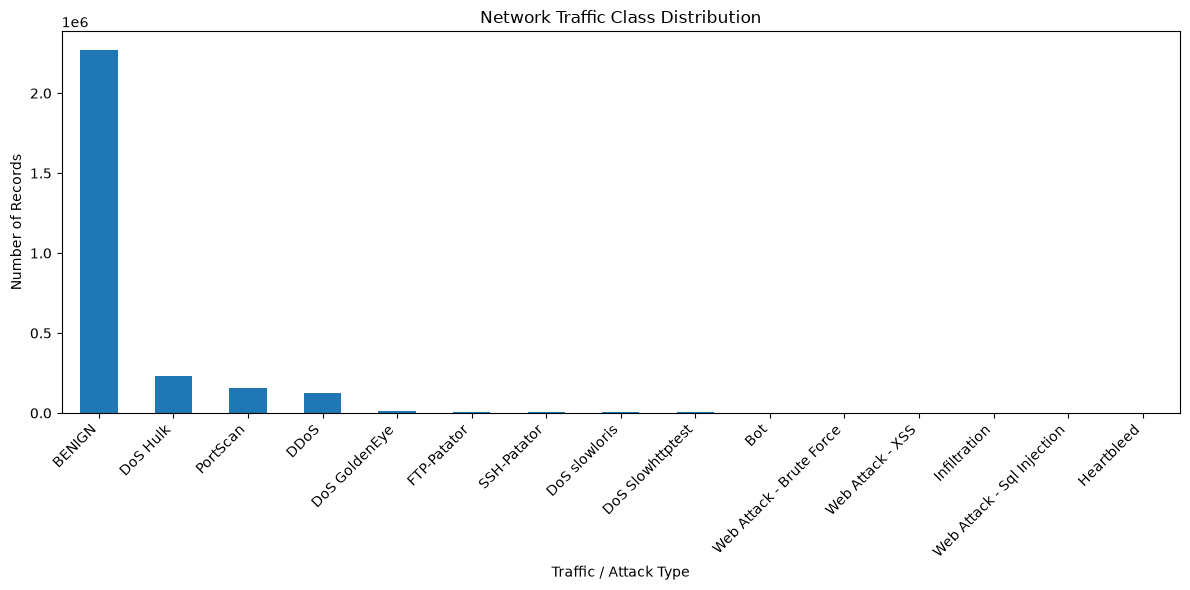

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

class_counts.plot(kind="bar")

plt.title("Network Traffic Class Distribution")
plt.xlabel("Traffic / Attack Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

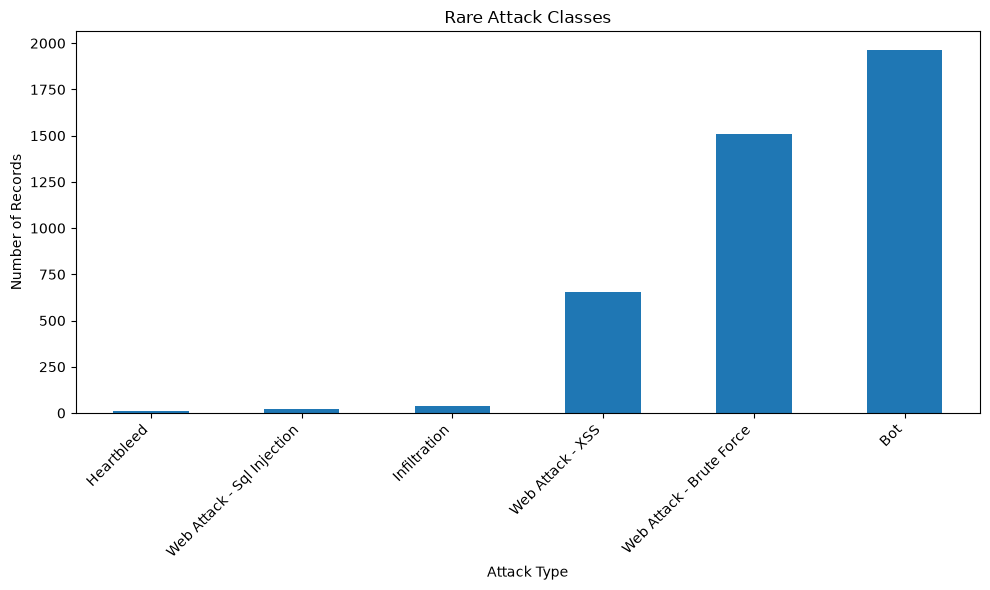

In [7]:
rare_classes = class_counts[class_counts < 5000]

plt.figure(figsize=(10, 6))

rare_classes.sort_values().plot(kind="bar")

plt.title("Rare Attack Classes")
plt.xlabel("Attack Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [8]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.0,80.0,443.0,65535.0
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.0,31316.0,3204828.5,119999998.0
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.0,2.0,2.0,5.0,219759.0
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.0,1.0,2.0,4.0,291922.0
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.0,12.0,62.0,187.0,12900000.0
...,...,...,...,...,...,...,...,...
Active Min,2830743.0,5.829582e+04,5.770923e+05,0.0,0.0,0.0,0.0,110000000.0
Idle Mean,2830743.0,8.316037e+06,2.363008e+07,0.0,0.0,0.0,0.0,120000000.0
Idle Std,2830743.0,5.038439e+05,4.602984e+06,0.0,0.0,0.0,0.0,76900000.0
Idle Max,2830743.0,8.695752e+06,2.436689e+07,0.0,0.0,0.0,0.0,120000000.0


In [9]:
numeric_df = df.select_dtypes(include=np.number)

stats = numeric_df.describe().T

print("Number of numerical features:", numeric_df.shape[1])
print("\nSummary statistics:")
display(stats)

Number of numerical features: 78

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.0,80.0,443.0,65535.0
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.0,31316.0,3204828.5,119999998.0
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.0,2.0,2.0,5.0,219759.0
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.0,1.0,2.0,4.0,291922.0
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.0,12.0,62.0,187.0,12900000.0
...,...,...,...,...,...,...,...,...
Active Min,2830743.0,5.829582e+04,5.770923e+05,0.0,0.0,0.0,0.0,110000000.0
Idle Mean,2830743.0,8.316037e+06,2.363008e+07,0.0,0.0,0.0,0.0,120000000.0
Idle Std,2830743.0,5.038439e+05,4.602984e+06,0.0,0.0,0.0,0.0,76900000.0
Idle Max,2830743.0,8.695752e+06,2.436689e+07,0.0,0.0,0.0,0.0,120000000.0


In [10]:
feature_ranges = numeric_df.max() - numeric_df.min()

largest_ranges = (
    feature_ranges
    .sort_values(ascending=False)
    .head(15)
)

print("Top 15 features by value range:")
display(largest_ranges.to_frame("Range"))

Top 15 features by value range:


,Range
Fwd Header Length.1,3.221688e+10
Fwd Header Length,3.221688e+10
Flow Bytes/s,2.332000e+09
Bwd Header Length,1.079580e+09
Total Length of Bwd Packets,6.554530e+08
Subflow Bwd Bytes,6.554530e+08
min_seg_size_forward,5.368708e+08
Flow IAT Min,1.200000e+08
Flow IAT Max,1.200000e+08
Flow IAT Mean,1.200000e+08


In [11]:
skewness = numeric_df.skew()

high_skew = (
    skewness.abs()
    .sort_values(ascending=False)
    .head(15)
)

print("Top 15 most skewed numerical features:")
display(high_skew.to_frame("Absolute Skewness"))

Top 15 most skewed numerical features:


,Absolute Skewness
Fwd Header Length.1,1325.073809
Fwd Header Length,1325.073809
Total Length of Fwd Packets,805.570539
Subflow Fwd Bytes,803.598592
Bwd Header Length,717.031304
min_seg_size_forward,474.535265
act_data_pkt_fwd,284.595228
Subflow Bwd Packets,244.679507
Total Backward Packets,244.679507
Subflow Fwd Packets,244.380553


In [12]:
correlation_sample = numeric_df.sample(
    n=10000,
    random_state=42
)

correlation_matrix = correlation_sample.corr()

print("Correlation matrix shape:")
print(correlation_matrix.shape)

Correlation matrix shape:
(78, 78)


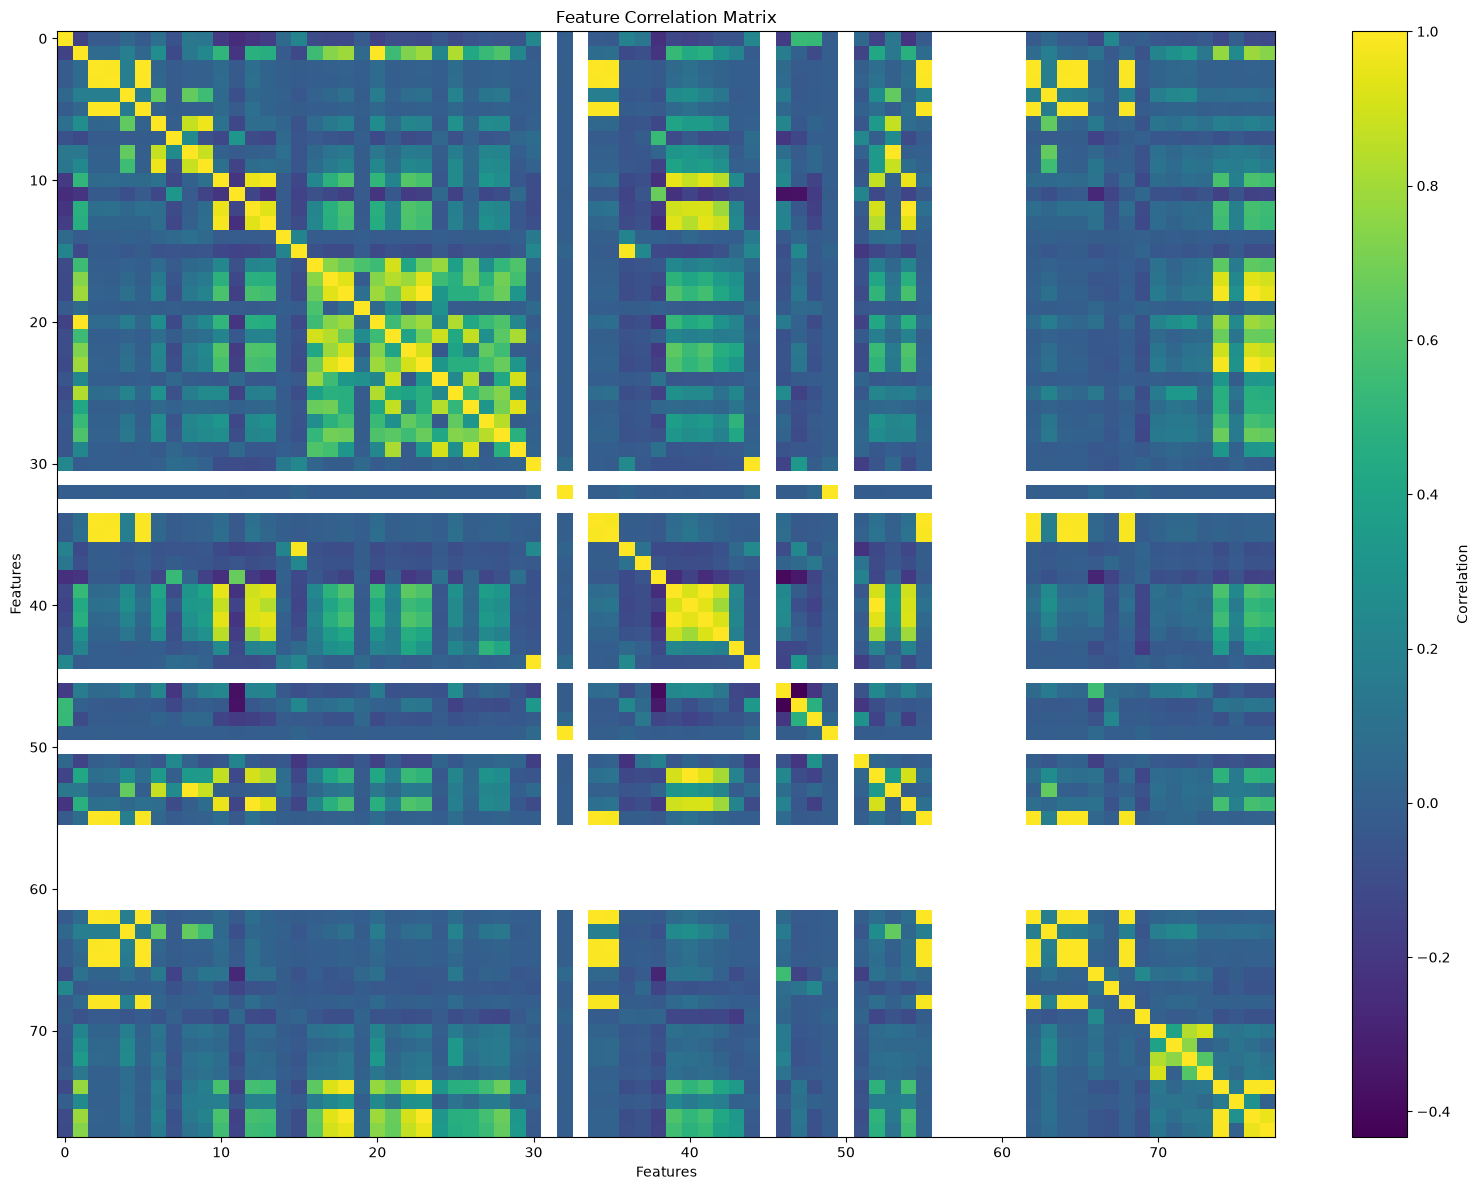

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.title("Feature Correlation Matrix")

plt.xlabel("Features")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [14]:
# Get upper triangle of correlation matrix
upper = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Find highly correlated feature pairs
high_correlations = (
    upper.stack()
    .reset_index()
)

high_correlations.columns = ["Feature 1", "Feature 2", "Correlation"]

high_correlations["Absolute Correlation"] = (
    high_correlations["Correlation"].abs()
)

high_correlations = high_correlations.sort_values(
    "Absolute Correlation",
    ascending=False
)

print("Top 20 most strongly correlated feature pairs:")

display(
    high_correlations.head(20)
)

Top 20 most strongly correlated feature pairs:


,Feature 1,Feature 2,Correlation,Absolute Correlation
2545,Fwd URG Flags,CWE Flag Count,1.000000,1.000000
990,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000000,1.000000
218,Total Fwd Packets,Subflow Fwd Packets,1.000000,1.000000
2384,Fwd PSH Flags,SYN Flag Count,1.000000,1.000000
677,Fwd Packet Length Mean,Avg Fwd Segment Size,1.000000,1.000000
455,Total Length of Bwd Packets,Subflow Bwd Bytes,1.000000,1.000000
2707,Fwd Header Length,Fwd Header Length.1,1.000000,1.000000
298,Total Backward Packets,Subflow Bwd Packets,1.000000,1.000000
375,Total Length of Fwd Packets,Subflow Fwd Bytes,1.000000,1.000000
98,Flow Duration,Fwd IAT Total,0.998952,0.998952


In [15]:
# Number of unique values for each numerical feature
unique_counts = numeric_df.nunique()

constant_features = unique_counts[unique_counts == 1]

print("Constant features:")
print(constant_features)

print("\nNumber of constant features:", len(constant_features))

Constant features:
Bwd PSH Flags           1
Bwd URG Flags           1
Fwd Avg Bytes/Bulk      1
Fwd Avg Packets/Bulk    1
Fwd Avg Bulk Rate       1
Bwd Avg Bytes/Bulk      1
Bwd Avg Packets/Bulk    1
Bwd Avg Bulk Rate       1
dtype: int64

Number of constant features: 8


In [16]:
# Features with 2 or fewer unique values
near_constant_features = unique_counts[unique_counts <= 2]

print("Features with 2 or fewer unique values:")
print(near_constant_features)

print(
    "\nNumber of features with 2 or fewer unique values:",
    len(near_constant_features)
)

Features with 2 or fewer unique values:
Fwd PSH Flags           2
Bwd PSH Flags           1
Fwd URG Flags           2
Bwd URG Flags           1
FIN Flag Count          2
SYN Flag Count          2
RST Flag Count          2
PSH Flag Count          2
ACK Flag Count          2
URG Flag Count          2
CWE Flag Count          2
ECE Flag Count          2
Fwd Avg Bytes/Bulk      1
Fwd Avg Packets/Bulk    1
Fwd Avg Bulk Rate       1
Bwd Avg Bytes/Bulk      1
Bwd Avg Packets/Bulk    1
Bwd Avg Bulk Rate       1
dtype: int64

Number of features with 2 or fewer unique values: 18


In [17]:
df["Traffic_Type"] = np.where(
    df["Label"] == "BENIGN",
    "Normal",
    "Attack"
)

traffic_counts = df["Traffic_Type"].value_counts()

print("Normal vs Attack Traffic:")
print(traffic_counts)

Normal vs Attack Traffic:
Traffic_Type
Normal    2273097
Attack     557646
Name: count, dtype: int64


In [18]:
traffic_percentages = (
    df["Traffic_Type"]
    .value_counts(normalize=True)
    * 100
)

print("Normal vs Attack Traffic (%):")
print(traffic_percentages.round(2))

Normal vs Attack Traffic (%):
Traffic_Type
Normal    80.3
Attack    19.7
Name: proportion, dtype: float64


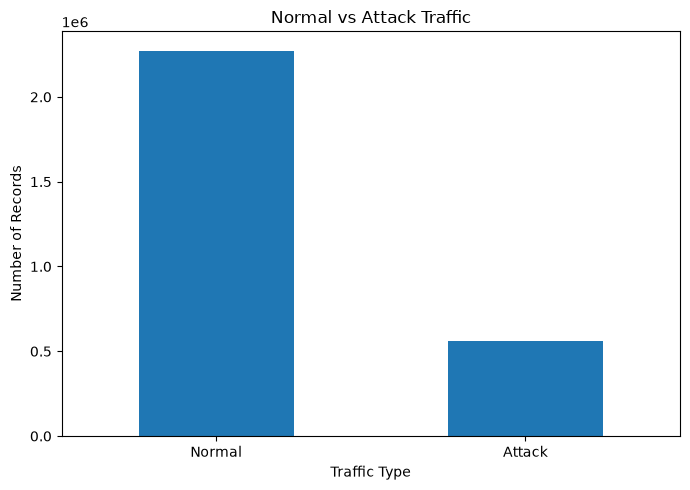

In [19]:
plt.figure(figsize=(7, 5))

traffic_counts.plot(kind="bar")

plt.title("Normal vs Attack Traffic")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [20]:
attack_df = df[df["Label"] != "BENIGN"]

attack_counts = attack_df["Label"].value_counts()

print("Attack Class Distribution:")
print(attack_counts)

Attack Class Distribution:
Label
DoS Hulk                      231073
PortScan                      158930
DDoS                          128027
DoS GoldenEye                  10293
FTP-Patator                     7938
SSH-Patator                     5897
DoS slowloris                   5796
DoS Slowhttptest                5499
Bot                             1966
Web Attack - Brute Force        1507
Web Attack - XSS                 652
Infiltration                      36
Web Attack - Sql Injection        21
Heartbleed                        11
Name: count, dtype: int64


In [21]:
attack_percentages = (
    attack_df["Label"]
    .value_counts(normalize=True)
    * 100
)

print("Attack Class Distribution (% of attacks):")
print(attack_percentages.round(2))

Attack Class Distribution (% of attacks):
Label
DoS Hulk                      41.44
PortScan                      28.50
DDoS                          22.96
DoS GoldenEye                  1.85
FTP-Patator                    1.42
SSH-Patator                    1.06
DoS slowloris                  1.04
DoS Slowhttptest               0.99
Bot                            0.35
Web Attack - Brute Force       0.27
Web Attack - XSS               0.12
Infiltration                   0.01
Web Attack - Sql Injection     0.00
Heartbleed                     0.00
Name: proportion, dtype: float64


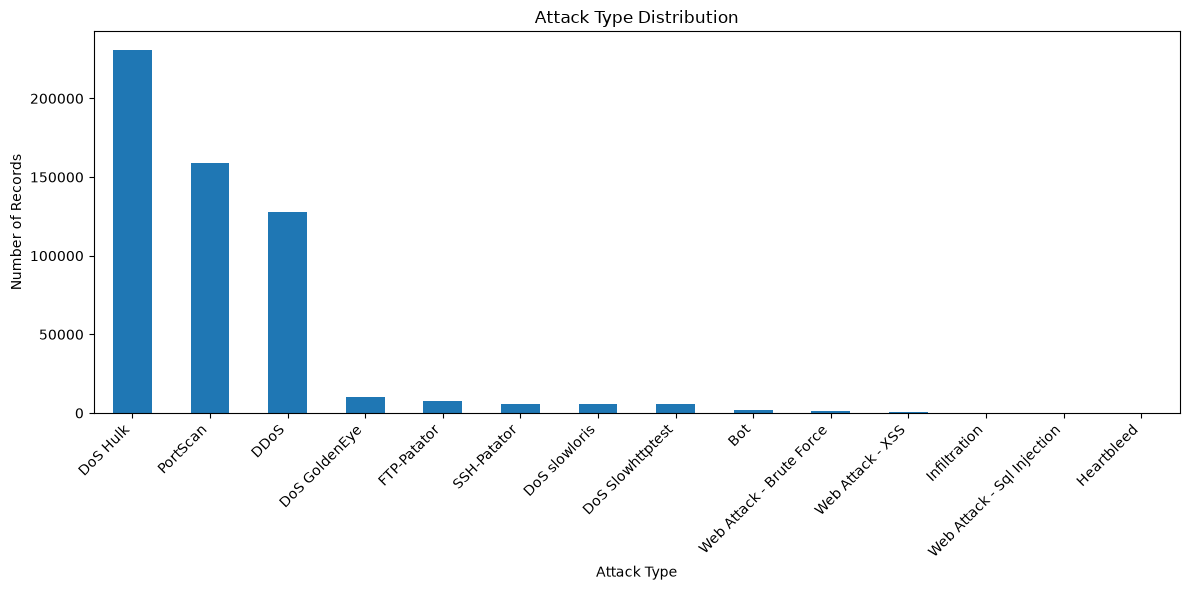

In [22]:
plt.figure(figsize=(12, 6))

attack_counts.plot(kind="bar")

plt.title("Attack Type Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [23]:
print("=" * 60)
print("NIDS EDA SUMMARY")
print("=" * 60)

print("\nDataset:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1] - 1)

print("\nTarget:")
print("Classes:", df["Label"].nunique())
print("Target column: Label")

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nConstant Features:")
print(len(constant_features))

print("\nFeatures with <= 2 Unique Values:")
print(len(near_constant_features))

print("\nNormal vs Attack:")
print(traffic_percentages.round(2))

print("\nMost Common Attack Types:")
print(attack_percentages.head(5).round(2))

print("\nHighly Correlated Feature Pairs:")
print(
    high_correlations[
        high_correlations["Absolute Correlation"] >= 0.90
    ].shape[0]
)

print("\nEDA completed successfully!")


NIDS EDA SUMMARY

Dataset:
Rows: 2830743
Columns: 79

Target:
Classes: 15
Target column: Label

Missing Values:
0

Constant Features:
8

Features with <= 2 Unique Values:
18

Normal vs Attack:
Traffic_Type
Normal    80.3
Attack    19.7
Name: proportion, dtype: float64

Most Common Attack Types:
Label
DoS Hulk         41.44
PortScan         28.50
DDoS             22.96
DoS GoldenEye     1.85
FTP-Patator       1.42
Name: proportion, dtype: float64

Highly Correlated Feature Pairs:
97

EDA completed successfully!
